In [1]:
#data format library
import h5py

#numpy
import numpy as np
import pandas as pd
import numpy.ma as ma
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
import matplotlib as mpl
plt.rcParams["font.family"] = "sans-serif"
matplotlib.rcParams['pdf.fonttype'] = 42
# %matplotlib notebook
import sys
sys.path.append('./utils/')
import matplotlib.colors as pltcolors
import os
import copy
import partitioning_methods as cl
import coarse_graining as cgm
import operator_calculations as op_calc
import delay_embedding as embed
import diffusion_maps as dmaps
import stats
import time

np.random.seed(42)

import importlib
importlib.reload(op_calc)

Extension for Scikit-learn* enabled (https://github.com/uxlfoundation/scikit-learn-intelex)


<module 'operator_calculations' from '/flash/StephensU/Gautam/Multiscale_phenotypic_variation/./utils/operator_calculations.py'>

In [2]:
Fig_path = '/flash/StephensU/Gautam/Figures/Comparing_MultiScale_Dynamics/Fig_zebrafish/'

In [3]:
condition_labels = ['Light (5x5cm)','Looming(5x5cm)','Dark_Transitions(5x5cm)','Dark (5x5cm)','3 min Light<->Dark(5x5cm)',
                    'Light (1x5cm)','Phototaxis','Optomotor Response (1x5cm)','Optokinetic Response (5x5cm)',
                    'Prey Capture Param. (2.5x2.5cm)','Prey Capture Param. RW. (2.5x2.5cm)',
                    'Prey Capture Rot.(2.5x2.5cm)','Prey capture Rot. RW. (2.5x2.5cm)','Light RW. (2.5x2.5cm)']

condition_recs = np.array([[453,463],[49,109],[22,49],[443,453],[0,22],
                           [121,133],[163,193],[109,121],[133,164],
                           [193,258],[304,387],[258,273],[273,304],
                           [387,443]])

In [4]:
conditions = np.zeros((np.max(condition_recs),2),dtype='object')
for k in range(len(condition_recs)):
    t0,tf = condition_recs[k]
    conditions[t0:tf,0] = np.arange(t0,tf)
    conditions[t0:tf,1] = [condition_labels[k] for t in range(t0,tf)]

In [43]:
f = h5py.File('/bucket/StephensU/Gautam/MATLAB/Zebrafish/'+'filtered_jmpool_kin.h5','r')
lengths = np.array(f['MetaData/lengths_data'],dtype=int)

ecs_allcond = ma.array(f['eye_convergence'])
time_Bout_allcond = ma.array(f['times_bouts']) #raw times bouts
bout_types= ma.array(f['bout_types'], dtype=int)
X_head_allcond= ma.array(f['head_pos'], dtype=int)
f.close()

In [46]:
ec = ecs_allcond
ec[ec<-10]=ma.masked
ec[ec==100]=ma.masked
mean_ec = ec.mean(axis=1)

# Estimate sequence lengths with eyes converged vs not

In [47]:
dts_param_ec_conds = np.zeros((2,3))
dts_param_noec_conds = np.zeros((2,3))

idx=9
f_0,f_f = condition_recs[idx]
print(condition_labels[idx])
dts_fish_naive_noec = []
dts_fish_naive_ec = []

for kf in range(f_0,f_f):
    mask = ec[kf]==1
    segments = np.where(np.abs(np.diff(np.concatenate([[False], mask, [False]]))))[0].reshape(-1, 2)  
    dts = np.hstack(np.diff(segments,axis=1))
    dts_fish_naive_noec.append(dts)
    mask = ec[kf]==2
    segments = np.where(np.abs(np.diff(np.concatenate([[False], mask, [False]]))))[0].reshape(-1, 2)  
    dts = np.hstack(np.diff(segments,axis=1))
    dts_fish_naive_ec.append(dts)
    



idx=10
f_0,f_f = condition_recs[idx]
print(condition_labels[idx])
dts_fish_rw_noec = []
dts_fish_rw_ec = []

for kf in range(f_0,f_f):
    mask = ec[kf]==1
    segments = np.where(np.abs(np.diff(np.concatenate([[False], mask, [False]]))))[0].reshape(-1, 2)  
    dts = np.hstack(np.diff(segments,axis=1))
    dts_fish_rw_noec.append(dts)
    mask = ec[kf]==2
    segments = np.where(np.abs(np.diff(np.concatenate([[False], mask, [False]]))))[0].reshape(-1, 2)  
    dts = np.hstack(np.diff(segments,axis=1))
    dts_fish_rw_ec.append(dts)

Prey Capture Param. (2.5x2.5cm)
Prey Capture Param. RW. (2.5x2.5cm)


[[2.48649843 2.37895591 2.60083806]
 [2.70440499 2.59804516 2.81511031]]
-0.1562083331475781 9.999000099990002e-05
[[7.09039226 6.29075677 8.02425002]
 [4.94836731 4.43678112 5.59089551]]


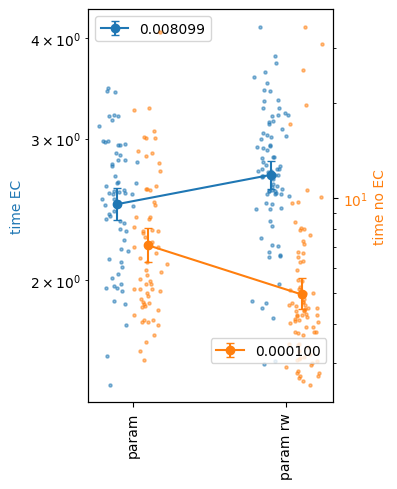

In [48]:
logmean_dts_fish_naive_ec = np.array([np.mean(np.log10(dts_fish_naive_ec[kf])) for kf in range(len(dts_fish_naive_ec))])
logmean_dts_fish_rw_ec = np.array([np.mean(np.log10(dts_fish_rw_ec[kf])) for kf in range(len(dts_fish_rw_ec))])
diff_data_ec = logmean_dts_fish_rw_ec.mean()-logmean_dts_fish_naive_ec.mean()


nboot=10000
dts_all = np.hstack([logmean_dts_fish_naive_ec,logmean_dts_fish_rw_ec])
n_naive = len(logmean_dts_fish_naive_ec)
diff_perm_ec = np.zeros((nboot))
for i in range(nboot):
    # print(n_naive,dts_all.shape)
    perm = np.random.permutation(len(dts_all))
    dts_naive_perm = dts_all[perm[:n_naive]]
    dts_rw_perm = dts_all[perm[n_naive:]]
    diff_perm_ec[i] = dts_rw_perm.mean(axis=0)-dts_naive_perm.mean(axis=0)

pval_ec = (np.sum(np.abs(diff_perm_ec) >= np.abs(diff_data_ec), axis=0) + 1) / (nboot + 1)
mean,cil,ciu = stats.bootstrap(logmean_dts_fish_naive_ec,n_times=10000)
dts_param_ec_conds[0,:] = 10**mean,10**cil[0],10**ciu[0]
mean,cil,ciu = stats.bootstrap(logmean_dts_fish_rw_ec,n_times=10000)
dts_param_ec_conds[1,:] = 10**mean,10**cil[0],10**ciu[0]

print(dts_param_ec_conds)

logmean_dts_fish_naive_noec = np.array([np.mean(np.log10(dts_fish_naive_noec[kf])) for kf in range(len(dts_fish_naive_noec))])
logmean_dts_fish_rw_noec = np.array([np.mean(np.log10(dts_fish_rw_noec[kf])) for kf in range(len(dts_fish_rw_noec))])
diff_data_noec = logmean_dts_fish_rw_noec.mean()-logmean_dts_fish_naive_noec.mean()


nboot=10000
dts_all = np.hstack([logmean_dts_fish_naive_noec,logmean_dts_fish_rw_noec])
n_naive = len(logmean_dts_fish_naive_noec)
diff_perm_noec = np.zeros((nboot))
for i in range(nboot):
    # print(n_naive,dts_all.shape)
    perm = np.random.permutation(len(dts_all))
    dts_naive_perm = dts_all[perm[:n_naive]]
    dts_rw_perm = dts_all[perm[n_naive:]]
    diff_perm_noec[i] = dts_rw_perm.mean(axis=0)-dts_naive_perm.mean(axis=0)

pval_noec = (np.sum(np.abs(diff_perm_noec) >= np.abs(diff_data_noec), axis=0) + 1) / (nboot + 1)
print(diff_data_noec,pval_noec)


mean,cil,ciu = stats.bootstrap(logmean_dts_fish_naive_noec,n_times=10000)
dts_param_noec_conds[0,:] = 10**mean,10**cil[0],10**ciu[0]
mean,cil,ciu = stats.bootstrap(logmean_dts_fish_rw_noec,n_times=10000)
dts_param_noec_conds[1,:] = 10**mean,10**cil[0],10**ciu[0]

print(dts_param_noec_conds)

fig, ax1 = plt.subplots(figsize=(4,5))

ax1.set_xticks(np.arange(2),['param' ,'param rw'],rotation=90)
ax1.set_ylabel('time EC', color='C0')
ax1.errorbar([-.1,.9],dts_param_ec_conds[:,0],yerr = [dts_param_ec_conds[:,0]-dts_param_ec_conds[:,1],
                                                          dts_param_ec_conds[:,2]-dts_param_ec_conds[:,0]],capsize=3,marker='o',c='C0',label='{:.6f}'.format(pval_ec))
ax1.scatter(np.random.normal(-.1,.05,len(logmean_dts_fish_naive_ec)),10**logmean_dts_fish_naive_ec,c='C0',s=5,alpha=.5)
ax1.scatter(np.random.normal(.9,.05,len(logmean_dts_fish_rw_ec)),10**logmean_dts_fish_rw_ec,c='C0',s=5,alpha=.5)

ax1.tick_params(axis='y', labelcolor='C0')
plt.yscale('log')

plt.legend()

ax2 = ax1.twinx()  # instantiate a second Axes that shares the same x-axis

ax2.set_ylabel('time no EC', color='C1')  # we already handled the x-label with ax1
ax2.errorbar([.1,1.1],dts_param_noec_conds[:,0],yerr = [dts_param_noec_conds[:,0]-dts_param_noec_conds[:,1],
                                                            dts_param_noec_conds[:,2]-dts_param_noec_conds[:,0]],capsize=3,marker='o',c='C1',label='{:.6f}'.format(pval_noec))
ax2.scatter(np.random.normal(0.1,.05,len(logmean_dts_fish_naive_noec)),10**logmean_dts_fish_naive_noec,c='C1',s=5,alpha=.5)
ax2.scatter(np.random.normal(1.1,.05,len(logmean_dts_fish_rw_noec)),10**logmean_dts_fish_rw_noec,c='C1',s=5,alpha=.5)
ax2.tick_params(axis='y', labelcolor='C1')
plt.legend(loc=(0.5,0.1))
fig.tight_layout()  # otherwise the right y-label is slightly clipped
plt.yscale('log')

# plt.savefig('time_EC_param.pdf')
plt.show()

In [49]:
dts_rot_ec_conds = np.zeros((2,3))
dts_rot_noec_conds = np.zeros((2,3))

idx=11
f_0,f_f = condition_recs[idx]
print(condition_labels[idx])
dts_fish_naive_noec = []
dts_fish_naive_ec = []

for kf in range(f_0,f_f):
    mask = ec[kf]==1
    segments = np.where(np.abs(np.diff(np.concatenate([[False], mask, [False]]))))[0].reshape(-1, 2)  
    dts = np.hstack(np.diff(segments,axis=1))
    dts_fish_naive_noec.append(dts)
    mask = ec[kf]==2
    segments = np.where(np.abs(np.diff(np.concatenate([[False], mask, [False]]))))[0].reshape(-1, 2)  
    dts = np.hstack(np.diff(segments,axis=1))
    dts_fish_naive_ec.append(dts)
    



idx=12
f_0,f_f = condition_recs[idx]
print(condition_labels[idx])
dts_fish_rw_noec = []
dts_fish_rw_ec = []

for kf in range(f_0,f_f):
    mask = ec[kf]==1
    segments = np.where(np.abs(np.diff(np.concatenate([[False], mask, [False]]))))[0].reshape(-1, 2)  
    dts = np.hstack(np.diff(segments,axis=1))
    dts_fish_rw_noec.append(dts)
    mask = ec[kf]==2
    segments = np.where(np.abs(np.diff(np.concatenate([[False], mask, [False]]))))[0].reshape(-1, 2)  
    dts = np.hstack(np.diff(segments,axis=1))
    dts_fish_rw_ec.append(dts)

Prey Capture Rot.(2.5x2.5cm)
Prey capture Rot. RW. (2.5x2.5cm)


[[2.63574668 2.47720227 2.80757022]
 [2.66312536 2.53755199 2.79480926]]
0.07703627091231069 0.0254974502549745
[[ 8.22856677  7.22434824  9.26817034]
 [ 9.82563141  9.02689962 10.64799307]]


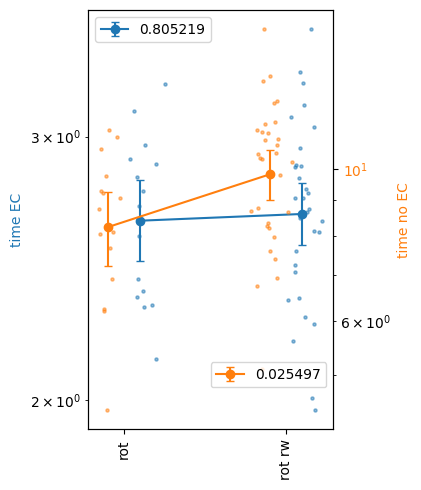

In [50]:
logmean_dts_fish_naive_ec = np.array([np.mean(np.log10(dts_fish_naive_ec[kf])) for kf in range(len(dts_fish_naive_ec))])
logmean_dts_fish_rw_ec = np.array([np.mean(np.log10(dts_fish_rw_ec[kf])) for kf in range(len(dts_fish_rw_ec))])
diff_data_ec = logmean_dts_fish_rw_ec.mean()-logmean_dts_fish_naive_ec.mean()


nboot=10000
dts_all = np.hstack([logmean_dts_fish_naive_ec,logmean_dts_fish_rw_ec])
n_naive = len(logmean_dts_fish_naive_ec)
diff_perm_ec = np.zeros((nboot))
for i in range(nboot):
    # print(n_naive,dts_all.shape)
    perm = np.random.permutation(len(dts_all))
    dts_naive_perm = dts_all[perm[:n_naive]]
    dts_rw_perm = dts_all[perm[n_naive:]]
    diff_perm_ec[i] = dts_rw_perm.mean(axis=0)-dts_naive_perm.mean(axis=0)

pval_ec = (np.sum(np.abs(diff_perm_ec) >= np.abs(diff_data_ec), axis=0) + 1) / (nboot + 1)
mean,cil,ciu = stats.bootstrap(logmean_dts_fish_naive_ec,n_times=10000)
dts_rot_ec_conds[0,:] = 10**mean,10**cil[0],10**ciu[0]
mean,cil,ciu = stats.bootstrap(logmean_dts_fish_rw_ec,n_times=10000)
dts_rot_ec_conds[1,:] = 10**mean,10**cil[0],10**ciu[0]

print(dts_rot_ec_conds)

logmean_dts_fish_naive_noec = np.array([np.mean(np.log10(dts_fish_naive_noec[kf])) for kf in range(len(dts_fish_naive_noec))])
logmean_dts_fish_rw_noec = np.array([np.mean(np.log10(dts_fish_rw_noec[kf])) for kf in range(len(dts_fish_rw_noec))])
diff_data_noec = logmean_dts_fish_rw_noec.mean()-logmean_dts_fish_naive_noec.mean()


nboot=10000
dts_all = np.hstack([logmean_dts_fish_naive_noec,logmean_dts_fish_rw_noec])
n_naive = len(logmean_dts_fish_naive_noec)
diff_perm_noec = np.zeros((nboot))
for i in range(nboot):
    # print(n_naive,dts_all.shape)
    perm = np.random.permutation(len(dts_all))
    dts_naive_perm = dts_all[perm[:n_naive]]
    dts_rw_perm = dts_all[perm[n_naive:]]
    diff_perm_noec[i] = dts_rw_perm.mean(axis=0)-dts_naive_perm.mean(axis=0)

pval_noec = (np.sum(np.abs(diff_perm_noec) >= np.abs(diff_data_noec), axis=0) + 1) / (nboot + 1)
print(diff_data_noec,pval_noec)


mean,cil,ciu = stats.bootstrap(logmean_dts_fish_naive_noec,n_times=10000)
dts_rot_noec_conds[0,:] = 10**mean,10**cil[0],10**ciu[0]
mean,cil,ciu = stats.bootstrap(logmean_dts_fish_rw_noec,n_times=10000)
dts_rot_noec_conds[1,:] = 10**mean,10**cil[0],10**ciu[0]

print(dts_rot_noec_conds)

fig, ax1 = plt.subplots(figsize=(4,5))

ax1.set_xticks(np.arange(2),['rot' ,'rot rw'],rotation=90)
ax1.set_ylabel('time EC', color='C0')
ax1.errorbar([.1,1.1],dts_rot_ec_conds[:,0],yerr = [dts_rot_ec_conds[:,0]-dts_rot_ec_conds[:,1],
                                                          dts_rot_ec_conds[:,2]-dts_rot_ec_conds[:,0]],capsize=3,marker='o',c='C0',label='{:.6f}'.format(pval_ec))
ax1.scatter(np.random.normal(.1,.05,len(logmean_dts_fish_naive_ec)),10**logmean_dts_fish_naive_ec,c='C0',s=5,alpha=.5)
ax1.scatter(np.random.normal(1.1,.05,len(logmean_dts_fish_rw_ec)),10**logmean_dts_fish_rw_ec,c='C0',s=5,alpha=.5)

ax1.tick_params(axis='y', labelcolor='C0')
plt.yscale('log')

plt.legend()

ax2 = ax1.twinx()  # instantiate a second Axes that shares the same x-axis

ax2.set_ylabel('time no EC', color='C1')  # we already handled the x-label with ax1
ax2.errorbar([-.1,.9],dts_rot_noec_conds[:,0],yerr = [dts_rot_noec_conds[:,0]-dts_rot_noec_conds[:,1],
                                                            dts_rot_noec_conds[:,2]-dts_rot_noec_conds[:,0]],capsize=3,marker='o',c='C1',label='{:.6f}'.format(pval_noec))
ax2.scatter(np.random.normal(-.1,.05,len(logmean_dts_fish_naive_noec)),10**logmean_dts_fish_naive_noec,c='C1',s=5,alpha=.5)
ax2.scatter(np.random.normal(.9,.05,len(logmean_dts_fish_rw_noec)),10**logmean_dts_fish_rw_noec,c='C1',s=5,alpha=.5)
ax2.tick_params(axis='y', labelcolor='C1')
plt.legend(loc=(0.5,0.1))
fig.tight_layout()  # otherwise the right y-label is slightly clipped
plt.yscale('log')
plt.savefig('time_EC_rot.pdf')
plt.show()

In [6]:
path_to_filtered_data = '/flash/StephensU/Gautam/Multiscale_phenotypic_variation//Results/Zebrafish/'
f = h5py.File(path_to_filtered_data+'distances_combined.h5','r')
Dc_q_data = np.array(f['Dc_q_data'],dtype=float)
Dc_q_eps = np.array(f['Dc_q_eps'],dtype=float)
q_range = np.array(f['q_range'],dtype=float)
f.close()

In [7]:
# D_eps_arr = np.stack(D_eps_list,axis=0)
D_arr = Dc_q_data
Eps_arr = Dc_q_eps

In [8]:
D_ratio = Dc_q_data/(Dc_q_eps)-1
for i in range(len(D_ratio)):
    np.fill_diagonal(D_ratio[i],0)
# D_ratio = Dc_q_data-Dc_q_reg_eps

D_ratio[D_ratio<0]=0
D_int = np.trapz(D_ratio,q_range,axis=0)
np.fill_diagonal(D_int,0)

/scratch/ipykernel_1793581/2748439544.py:1: RuntimeWarning: invalid value encountered in divide
  D_ratio = Dc_q_data/(Dc_q_eps)-1


In [9]:
from scipy.sparse.linalg import eigs
sorted_d = np.sort(D_int, axis=1)
k=50
M = dmaps.self_tuning_diffusion_tmat(D_int,sorted_d,k,1)

In [10]:
from scipy.sparse.linalg import eigs
# P = L / L.sum(axis=1)[:, np.newaxis]
diff_eig, diff_ev = eigs(M,k=10)
diff_inv_mes = op_calc.stationary_distribution(M)
diff_eigvecs = diff_ev / np.sqrt((diff_ev**2 * diff_inv_mes[:, None]).sum(axis=0))

sorted_indices = np.argsort(diff_eig.real)[::-1]
diff_eig = diff_eig[sorted_indices].real
diff_eig[diff_eig<1e-12] = 0
diff_dists = diff_eig*(diff_eigvecs[:,sorted_indices].real)

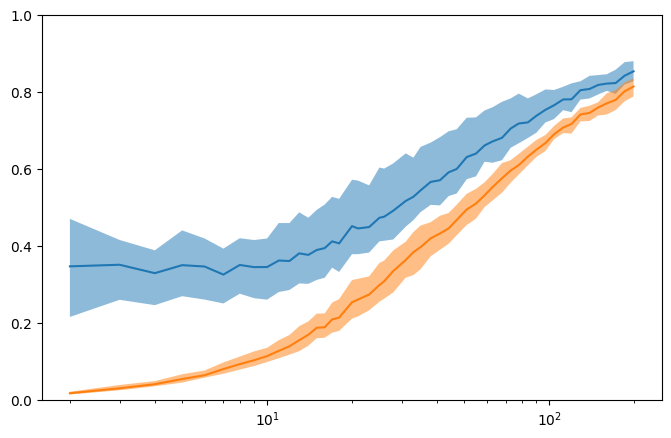

In [11]:
conds_to_comp = [[11],[12]]
cond_recs1 = []
cond_recs2 = []
for c in conds_to_comp[0]:
    cond_recs1.append(np.where(conditions[:,1] == condition_labels[c])[0])
cond_recs1 = np.hstack(cond_recs1)

for c in conds_to_comp[1]:
    cond_recs2.append(np.where(conditions[:,1] == condition_labels[c])[0])
cond_recs2 = np.hstack(cond_recs2)


D_here = Dc_q_data[:,cond_recs1,:][:,:,cond_recs2]
Eps_here = Dc_q_eps[:,cond_recs1,:][:,:,cond_recs2]


plt.figure(figsize=(8,5))
mean = D_here.max(axis=2).mean(axis=1)
# mean= np.median(Dc_q_data.max(axis=2),axis=1)
cil = np.percentile(D_here.max(axis=2),2.5,axis=1)
ciu =  np.percentile(D_here.max(axis=2),97.5,axis=1)
plt.plot(q_range,mean,label='data')
plt.fill_between(q_range,cil,ciu,alpha=.5)

mean = Eps_here.max(axis=2).mean(axis=1)
# mean = np.median(Dc_q_eps.max(axis=2),axis=1)
cil = np.percentile(Eps_here.max(axis=2),2.5,axis=1)
ciu =  np.percentile(Eps_here.max(axis=2),97.5,axis=1)
plt.plot(q_range,mean,label='eps')
plt.fill_between(q_range,cil,ciu,alpha=.5)
# plt.axvline(20,c='k',ls='--')
# plt.axvline(3,c='k',ls='--')
# plt.axvline(12,c='k',ls='--')
# plt.axvline(91,c='k',ls='--')
plt.xscale('log')
# plt.yscale('log')
# plt.xlabel('q')
# plt.ylabel('<D>')
plt.ylim(0,1.0)
# plt.savefig(Fig_path+'/dist_v_eps_rotn_rw.pdf')
plt.show()

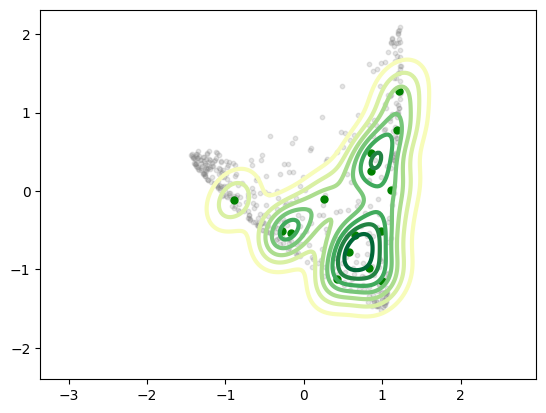

In [12]:
fig, ax = plt.subplots(1,1)
from scipy.stats import gaussian_kde
cmaps = ['YlGn']
colors_ = ['Green']
nonpc_cond_recs = np.arange(0,193)

plt.scatter(diff_dists[:,1],diff_dists[:,2],c='grey',alpha=0.2,s=10)

for i,cond in enumerate([11]):
    idx = np.where(conditions[:,1] == condition_labels[cond])[0]
    plt.scatter(diff_dists[idx,1],diff_dists[idx,2],c=colors_[i],alpha=1,s=25)
    values = diff_dists[idx,1:3].T
    kernel = gaussian_kde(values,bw_method=0.4)
    X,Y = np.meshgrid(np.linspace(-2.4,2,200),np.linspace(-2.4,2,200))
    positions = np.vstack([X.ravel(), Y.ravel()])
    img = np.reshape(kernel(positions).T, X.shape)
    plt.contour(X,Y, img, cmap=cmaps[int(i)], linewidths=3)

    X = diff_dists[idx,1:3]
    X = X - np.mean(X,axis=0)
    cov = np.cov(X.T)
    e1, ev2 = np.linalg.eig(cov)
    ms = [np.median(diff_dists[idx,1],axis=0),np.median(diff_dists[idx,2],axis=0)]
    # plt.arrow(ms[0],ms[1], -1*20.*e1[0]*ev2[0,0], -1*20.*e1[0]*ev2[1,0], width = 0.003, alpha=0.8, ec='k',zorder=10,color = 'C{}'.format(i))
    # plt.arrow(ms[0],ms[1], 20.*e1[1]*ev2[0,1], 20.*e1[1]*ev2[1,1], width = 0.003, alpha=0.8, ec='k',zorder=10,color = 'C{}'.format(i))
    
    # plt.colorbar()
plt.axis('equal')
# plt.savefig(Fig_path+'dataset_densities_pcrotrw.pdf')
plt.show()

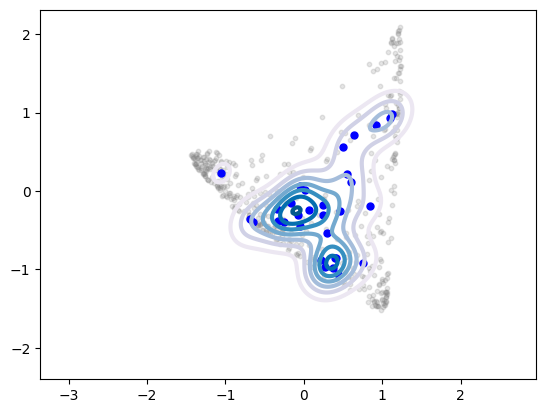

In [13]:
fig, ax = plt.subplots(1,1)
from scipy.stats import gaussian_kde
cmaps = ['PuBu']
colors_ = ['Blue']
nonpc_cond_recs = np.arange(0,193)

# diff_dists[:,2] = -1*diff_dists[:,2]

plt.scatter(diff_dists[:,1],diff_dists[:,2],c='grey',alpha=0.2,s=10)

for i,cond in enumerate([12]):
    idx = np.where(conditions[:,1] == condition_labels[cond])[0]
    plt.scatter(diff_dists[idx,1],diff_dists[idx,2],c=colors_[i],alpha=1,s=25)
    values = diff_dists[idx,1:3].T
    kernel = gaussian_kde(values,bw_method=0.4)
    X,Y = np.meshgrid(np.linspace(-2.4,2,200),np.linspace(-2.4,2,200))
    positions = np.vstack([X.ravel(), Y.ravel()])
    img = np.reshape(kernel(positions).T, X.shape)
    plt.contour(X,Y, img, cmap=cmaps[int(i)], linewidths=3)

    X = diff_dists[idx,1:3]
    X = X - np.mean(X,axis=0)
    cov = np.cov(X.T)
    e1, ev2 = np.linalg.eig(cov)
    ms = [np.median(diff_dists[idx,1],axis=0),np.median(diff_dists[idx,2],axis=0)]
    # plt.arrow(ms[0],ms[1], -1*20.*e1[0]*ev2[0,0], -1*20.*e1[0]*ev2[1,0], width = 0.003, alpha=0.8, ec='k',zorder=10,color = 'C{}'.format(i))
    # plt.arrow(ms[0],ms[1], 20.*e1[1]*ev2[0,1], 20.*e1[1]*ev2[1,1], width = 0.003, alpha=0.8, ec='k',zorder=10,color = 'C{}'.format(i))
    
    # plt.colorbar()
plt.axis('equal')
# plt.savefig(Fig_path+'dataset_densities_pcrotrw.pdf')
plt.show()

In [14]:
path_to_filtered_data = '/flash/StephensU/Gautam/HMD/Results/Zebrafish/'
f =  h5py.File(path_to_filtered_data + '/cg_labels_tree_minrho.h5')
labels_tree = np.array(f['labels_tree'],dtype=int)
print(f.keys())
f.close()

<KeysViewHDF5 ['labels_tree']>


In [18]:
## Load symbolic sequences

path_to_filtered_data = '/bucket/StephensU/Gautam/HMD/Results/Zebrafish/'
f = h5py.File(path_to_filtered_data + 'microstate_labels.h5')
lengths_all = np.array(f['MetaData/lengths_data'], dtype=int)
labels_fish_allrec = ma.array(f['labels_fish'],dtype=int)
state_trajs = ma.array(f['state_trajs'])
f.close()

# lengths_all = np.load('/Users/gautam.sridhar/Documents/Repos/ZebraBouts/Datasets/Full_Data/lengths_ex2_recordings.npy')
# lengths_all = lengths

In [21]:
# recs_ = np.asarray(conditions[:,0], dtype=int)

to_mask = 1300

# maxL = np.max(lengths_all[recs_])
maxL = np.max(lengths_all)

labels_fish_allrec[labels_fish_allrec == to_mask] = ma.masked

# labels_fishrec = to_mask * ma.ones((len(recs_), maxL))
# labels_fishrec = labels_fish_allrec[recs_,:maxL+2]
# labels_fishrec = np.delete(labels_fishrec,4,0)

# labels_fishrec[labels_fishrec == to_mask] = ma.masked
labels_fish = labels_fish_allrec

# lengths_rem = np.delete(lengths_all, recs_remove)
lengths_rem = lengths_all

In [22]:
print(condition_labels)

['Light (5x5cm)', 'Looming(5x5cm)', 'Dark_Transitions(5x5cm)', 'Dark (5x5cm)', '3 min Light<->Dark(5x5cm)', 'Light (1x5cm)', 'Phototaxis', 'Optomotor Response (1x5cm)', 'Optokinetic Response (5x5cm)', 'Prey Capture Param. (2.5x2.5cm)', 'Prey Capture Param. RW. (2.5x2.5cm)', 'Prey Capture Rot.(2.5x2.5cm)', 'Prey capture Rot. RW. (2.5x2.5cm)', 'Light RW. (2.5x2.5cm)']


# Estimate state prevalence in RW vs Naive

In [33]:
f_0,f_f = condition_recs[11]
p_naive=np.zeros((f_f-f_0,nstates))
for kf in range(f_0,f_f):
    l,c = np.unique(qlabels_fish[kf].compressed(),return_counts=True)
    p_naive[kf-f_0,l]=c/c.sum()

f_0,f_f = condition_recs[12]

p_rw=np.zeros((f_f-f_0,nstates))
for kf in range(f_0,f_f):
    l,c = np.unique(qlabels_fish[kf].compressed(),return_counts=True)
    p_rw[kf-f_0,l]=c/c.sum()

ratio_data=np.log2(p_rw.mean(axis=0)/p_naive.mean(axis=0))
diff_data = p_rw.mean(axis=0)-p_naive.mean(axis=0)

In [34]:
ratio_boot = np.zeros((nboot,nstates))

for i in range(nboot):
    sel_rw = np.random.randint(0,len(p_rw),len(p_rw))
    sel_naive = np.random.randint(0,len(p_naive),len(p_naive))
    ratio_boot[i] = np.log2(p_rw[sel_rw].mean(axis=0)/p_naive[sel_naive].mean(axis=0))
cil_ratio = np.percentile(ratio_boot,2.5,axis=0)
ciu_ratio = np.percentile(ratio_boot,97.5,axis=0)

In [35]:
p_all = np.vstack([p_naive,p_rw])
nboot=5000
diff_perm = np.zeros((nboot,nstates))
for i in range(nboot):
    perm = np.random.permutation(len(p_all))
    p_naive_perm = p_all[perm[:len(p_naive)]]
    p_rw_perm = p_all[perm[len(p_naive):]]
    diff_perm[i] = p_rw_perm.mean(axis=0)-p_naive_perm.mean(axis=0)

pvals = (np.sum(np.abs(diff_perm) >= np.abs(diff_data), axis=0) + 1) / (nboot + 1)

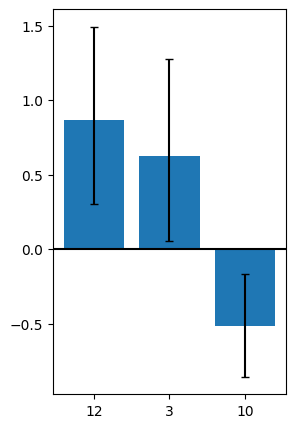

In [36]:
plt.figure(figsize=(3,5))

sel = np.logical_and(pvals<0.05,np.abs(ratio_data)>0.5)
sel_state = np.arange(nstates)[sel][np.argsort(ratio_data[sel])]
sel_state = sel_state[np.argsort(ratio_data[sel_state])[::-1]]

plt.bar(np.arange(len(sel_state)),ratio_data[sel_state],yerr = [ratio_data[sel_state]-cil_ratio[sel_state],
                                                                    ciu_ratio[sel_state]-ratio_data[sel_state]],capsize=3)
plt.axhline(0,c='k')
plt.xticks(np.arange(len(sel_state)),np.arange(20)[sel_state])
# plt.savefig('log_fold_change_rotifers_pvalue<0.05_ratio>0.5.pdf')
plt.show()


In [40]:
bout_type_labels = dict([[1,'Short_CS'],
[2,'Long_CS'],
[3, 'BS'],
[4,'O_bend'],
[5,'J_turn'],
[6,'SLC'],
[7,'Slow1'],
[8,'RT'],
[9,'Slow2'],
[10,'LLC'],
[11,'AS'],
[12,'SAT'],
[13,'HAT']])

In [41]:
print(sel_state)

[12  3 10]


In [44]:
bout_types[bout_types>13]=ma.masked

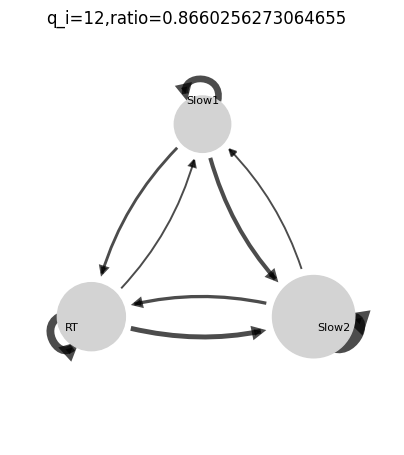

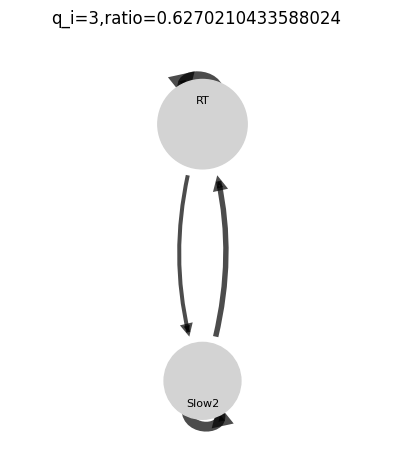

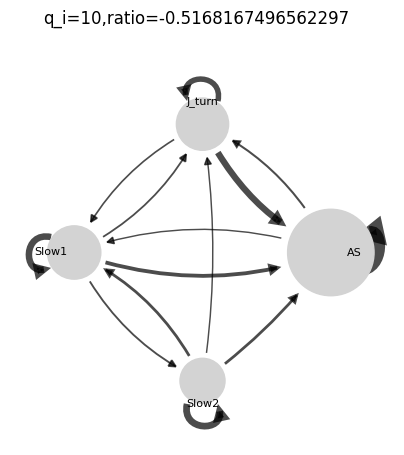

In [45]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch
from matplotlib.path import Path


def regular_polygon_np(n, radius=1.0, center=(0.0, 0.0), start_angle=np.pi/2):
    theta = start_angle + 2*np.pi*np.arange(n)/n
    return np.column_stack((center[0] + radius*np.cos(theta),
                            center[1] + radius*np.sin(theta)))


p_thresh = 0.1
labels_all = np.array(list(bout_type_labels.values()))

for q_i in sel_state:
    P_c = op_calc.transition_matrix(
        ma.array([ma.hstack(bout_types)[ma.hstack(qlabels_fish) == q_i]], dtype=int), delay=1)
    pi = op_calc.stationary_distribution(P_c)
    sel = pi > p_thresh
    n = sel.sum()
    
    cs = regular_polygon_np(n)
    P_red = P_c.toarray()[sel, :][:, sel]
    
    labels_sel = np.asarray(labels_all)[sel]
    
    sizes = pi[sel] * 10000
    rad_pt = np.sqrt(sizes / np.pi)
    
    fig, ax = plt.subplots(figsize=(5, 5))
    plt.suptitle('q_i={},ratio={}'.format(q_i,ratio_data[q_i]))
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_xlim(-1.5, 1.5)
    ax.set_ylim(-1.5, 1.5)
    
    ax.scatter(
        cs[:, 0], cs[:, 1],
        s=sizes,
        zorder=3,
        c='lightgray'
    )
    
    # labels pushed radially outward
    for i in range(n):
        u = cs[i] / np.linalg.norm(cs[i])
        ax.text(
            *(cs[i] + 0.18 * u),
            labels_sel[i],
            ha='center',
            va='center',
            fontsize=8,
            zorder=4
        )
    
    edge_thresh = p_thresh
    self_thresh = edge_thresh   # or use edge_thresh if you want all self-transitions
    
    mask = ~np.eye(n, dtype=bool)
    pmax = max(P_red[mask].max(), np.diag(P_red).max())
    
    # -------------------------------------------------------------------------
    # self-transition arrows
    # -------------------------------------------------------------------------
    for i in range(n):
        if P_red[i, i] < self_thresh:
            continue
    
        c = cs[i]
    
        # outward radial direction
        u = c / np.linalg.norm(c)
    
        # perpendicular direction
        v = np.array([-u[1], u[0]])
    
        # loop geometry in data coordinates
        loop_offset = 0.18
        loop_width  = 0.12
        loop_height = 0.22
    
        start = c + loop_offset * u - loop_width * v
        end   = c + loop_offset * u + loop_width * v
    
        ctrl1 = c + (loop_offset + loop_height) * u - 1.4 * loop_width * v
        ctrl2 = c + (loop_offset + loop_height) * u + 1.4 * loop_width * v
    
        path = Path(
            [start, ctrl1, ctrl2, end],
            [Path.MOVETO, Path.CURVE4, Path.CURVE4, Path.CURVE4]
        )
    
        arr = FancyArrowPatch(
            path=path,
            arrowstyle='-|>',
            mutation_scale=12,
            # linewidth=0.5 + 4 * P_red[i, i] / pmax,
            linewidth = 20*P_red[i,i],
            color='k',
            alpha=0.7,
            zorder=2,
            joinstyle='miter',
            capstyle='butt'
        )
    
        arr.set_gid(f'self_edge_{i}')
        ax.add_patch(arr)
    
    
    # -------------------------------------------------------------------------
    # normal non-self transition arrows
    # -------------------------------------------------------------------------
    for i in range(n):
        for j in range(n):
    
            if i == j:
                continue
    
            if P_red[i, j] < edge_thresh:
                continue
    
            if P_red[j, i] >= edge_thresh:
                curve = 0.18
            else:
                curve = 0.08
    
            arr = FancyArrowPatch(
                posA=cs[i],
                posB=cs[j],
                connectionstyle=f"arc3,rad={curve}",
                arrowstyle='-|>',
                mutation_scale=12,
                shrinkA=rad_pt[i] + 2,
                shrinkB=rad_pt[j] + 2,
                # linewidth=0.5 + 4 * P_red[i, j] / pmax,
                linewidth = 10*P_red[i,j],
                color='k',
                alpha=0.7,
                zorder=2,
                joinstyle='miter',
                capstyle='butt'
            )
    
            arr.set_gid(f'edge_{i}_{j}')
            ax.add_patch(arr)
    
    # fig.savefig(f'trans_matrix_q_i_{q_i}.svg', bbox_inches='tight')
    # fig.savefig(f'trans_matrix_q_i_{q_i}.pdf', bbox_inches='tight')
    plt.show()

In [72]:
idx=11
print(condition_labels[idx])
f_0,f_f = condition_recs[idx]

dts_naive = []

for kf in range(f_0,f_f):
    mask = qlabels_fish[kf]==10
    segments = np.where(np.abs(np.diff(np.concatenate([[False], mask, [False]]))))[0].reshape(-1, 2)
    dts_naive.append(np.hstack(np.diff(segments,axis=1)))


idx=12
print(condition_labels[idx])
f_0,f_f = condition_recs[idx]

dts_rw = []

for kf in range(f_0,f_f):
    mask = qlabels_fish[kf]==10
    segments = np.where(np.abs(np.diff(np.concatenate([[False], mask, [False]]))))[0].reshape(-1, 2)
    dts_rw.append(np.hstack(np.diff(segments,axis=1)))

logmean_dts_naive = [np.mean(np.log10(dts_naive[kf])) for kf in range(len(dts_naive))]
logmean_dts_rw = [np.mean(np.log10(dts_rw[kf])) for kf in range(len(dts_rw))]
diff_data = np.mean(logmean_dts_rw)-np.mean(logmean_dts_naive)
print(diff_data)
dts_all = np.hstack([logmean_dts_naive,logmean_dts_rw])
n_naive = len(logmean_dts_naive)
nboot=100000
diff_perm = np.zeros((nboot))
for i in range(nboot):
    perm = np.random.permutation(len(dts_all))
    dts_naive_perm = dts_all[perm[:n_naive]]
    dts_rw_perm = dts_all[perm[n_naive:]]
    diff_perm[i] = dts_rw_perm.mean(axis=0)-dts_naive_perm.mean(axis=0)

pval = (np.sum(np.abs(diff_perm) >= np.abs(diff_data), axis=0) + 1) / (nboot + 1)
print(pval)



Prey Capture Rot.(2.5x2.5cm)
Prey capture Rot. RW. (2.5x2.5cm)
-0.03238843664750923
0.03550964490355096


1.5945755533576775 1.4916033239294009 1.7209465949529992


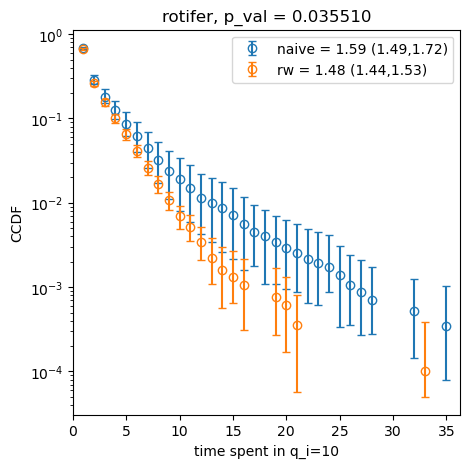

In [73]:
plt.figure(figsize=(5,5))
plt.title('rotifer, p_val = {:.6f}'.format(pval))
x,y = get_errorbar_dist(dts_naive,0,60)
# sel=x<15]
# x = x[x<15]
# y = y[y[:,0]<15,:]
mean,cil,ciu = stats.bootstrap([np.mean(np.log10(dts_naive[kf])) for kf in range(len(dts_naive))],n_times=10000)
print(10**mean,10**cil[0],10**ciu[0])

plt.errorbar(x,y[:,0],yerr = [y[:,0]-y[:,1],y[:,2]-y[:,0]],label='naive = {:.3} ({:.3},{:.3})'.format(10**mean,10**cil[0],10**ciu[0]),capsize=3,fmt='o',mfc='none')
x,y = get_errorbar_dist(dts_rw,0,60)
mean,cil,ciu = stats.bootstrap([np.mean(np.log10(dts_rw[kf])) for kf in range(len(dts_rw))],n_times=10000)
plt.errorbar(x,y[:,0],yerr = [y[:,0]-y[:,1],y[:,2]-y[:,0]],label='rw = {:.3} ({:.3},{:.3})'.format(10**mean,10**cil[0],10**ciu[0]),capsize=3,fmt='o',mfc='none')
plt.yscale('log')
plt.legend()
plt.xlabel('time spent in q_i=10')
plt.ylabel('CCDF')
plt.xlim(0*x.min(),x.max()*1.1)
plt.savefig('time_in_q_i_10_rotifer.pdf')
# plt.xscale('log')
plt.show()